In [19]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
#import seaborn as sns
import sys
import glob
import os
import math
import seaborn as sns

In [21]:
#| export

def get_initials():
    
    #control run initial parameterization
    control_run = pd.read_csv('../data/control_run_SDE.csv')
    #print(len(control_run))
    #remove transient
    control_dropped = control_run.loc[control_run['Run name']>=10]
    #access every 5th row (time unit)
    control_5th = control_dropped.iloc[::40]
    control_5th.head()
    cols = ['T', 'S']
    temp_list, salt_list = [control_5th[c].tolist() for c in cols]

    return temp_list,salt_list

zeros=pd.read_csv('cov_df_new.csv')

In [28]:
def smoothabs(x, xi=10000):
    """Smooth absolute value function"""
    return x * np.tanh(x * xi)

def calculate_coeffs(col,t0):
    #instead of this, will calculate based on this equation
    #cov,vT,vS  = row['corr_TS'],row['sigma_T'],row['sigma_S']

    y = zeros[col].to_numpy()
    y = np.asarray(y)
    N=len(y)
    x = np.linspace(0, 100, N)
    
    
    a3, a2, a1, a0 = np.polyfit(x, y, 3)  

    value=a0 + a1*t0 + a2*t0**2 + a3*t0**3
    #print("Value for fit",value)
    return value

def get_noise(t0):

    dt_slow=0.025
    vT=calculate_coeffs('sigmaT',t0)
    vS=calculate_coeffs('sigmaS',t0)
    cov=calculate_coeffs('cov_TS',t0)
    ##print("cov",cov)
    #print("covariance:",cov,"vT:",vT,'VS:',vS)
    
    z = np.random.randn(2)
    dW = np.sqrt(dt_slow) * z        
    x1 = vT * dW[0]
    x2 = vS * (cov * z[0] + np.sqrt(max(0,1-cov**2)) * z[1]) * np.sqrt(dt_slow)
    #plt.plot(x1)
    #plt.plot(x2)
    #print("x1:",x1,"x2:",x2)
    
    return x1,x2

def simulate_with_resampling(T,S):
    """Gottwald model functions without sea ice"""
    mu = 7.5
    epsilon_a = 0.34
    dt_slow=0.025
    x_avg=1.0147
    delta_avg=1.7463
    sigma_1=0.00934
    sigma_0 = 0.9
    theta_0=1
    theta_1=0.0195
    trajs=[]
    Ts=[]
    Ss=[]
    ts=[]
    all_runs=[]

    #print('state at first:',state)
    #if np.isnan([T],[S]).any():
     #   T,S = np.array([0, 0])

    #plt.plot(x1,x2)
    for temp in range(len(T)):
        #print(len(T))
        current_t = T[temp]
        current_s = S[temp]

        for i in range(100):

            Ts.append(current_t)
            Ss.append(current_s)

            x1,x2=get_noise(current_t)
            delta_avg_corr = calculate_coeffs('S_deviation',current_t)
            x_avg_corr = calculate_coeffs('T_deviation',current_t)
            #print("After adding:",current_t,current_s)

            #print("x1 and x2:",x1,',',x2)
            dT_det = -1/epsilon_a*(current_t-(theta_0 + x_avg_corr)) - current_t - mu*smoothabs(current_s - current_t)*current_t
            dS_det =  - current_s- mu*smoothabs(current_s - current_t)*current_s + sigma_0 + delta_avg_corr
            current_t += dT_det *dt_slow + x1   # add correlated noise
            current_s += dS_det *dt_slow + x2

            ts.append(i)

        trajs.append(temp)


    #print(amoc_df.head())
    #print(Ts)

    #Convert this run to a dataframe
    run_df = pd.DataFrame()
    run_df['T']=Ts
    run_df['S']=Ss
    run_df['AMOC']=run_df['T']-run_df['S']
    run_df['t']=np.arange(len(run_df)) % 100
    run_df['traj'] = np.repeat(np.arange(int(np.ceil(len(run_df) / 100))), 100)[:len(run_df)]

    #Store it
    all_runs.append(run_df)
    #print(run_df.loc[run_df['traj']==2])

    #After the loop, combine everything:
    amoc_df = pd.concat(all_runs, ignore_index=True)

    return amoc_df

In [29]:
#Rare Event Algorithm functions

def resample(ntrajs,traj_list,dt,k,amoc_df,agg_label,agg_run):
    # resampling
    
    # compute weights
    obsint=np.empty(ntrajs)
    #print("Number of trajs:",ntrajs)
    for traj in range(ntrajs):
        obsint[traj]=np.sum(traj_list[traj])*dt
    W=np.exp(k*(obsint-np.mean(obsint)))
    # compute the normalizer and the normalized weights
    R=sum(W)/ntrajs
    w=W/R
    
    # compute the number of clones generated by trajectory
    nc=np.empty(ntrajs)
    for traj in range(ntrajs):
        nc[traj]=math.floor(w[traj]+np.random.uniform(0,1))
    
    # compute total number of clones and the difference with original ensemble size 
    Nc=sum(nc)
    dN=Nc-ntrajs
    
    #logic for keeping clones proportional to ancestors
    label=np.arange(ntrajs)
    if dN<0:
        traj2clone=np.empty(int(-dN))
        for traj in range(int(-dN)):    
            traj2clone[traj]=np.random.choice(label,p=nc/sum(nc))  
        for traj in range(int(-dN)):
            nc[int(traj2clone[traj])]=nc[int(traj2clone[traj])]+1
    
    if dN>0:
        traj2kill=np.empty(int(dN))
        for traj in range(int(dN)):
            traj2kill[traj]=np.random.choice(label,p=nc/sum(nc))
            nc[int(traj2kill[traj])]=nc[int(traj2kill[traj])]-1

    killedlabel=np.empty(ntrajs)
    for traj in range(ntrajs):
        if nc[traj]>0:
            killedlabel[traj]=0
        else:
            killedlabel[traj]=1
    
    #assign initialization labels to clones
    initlabel=np.arange(ntrajs)
    udkilledlabel=np.empty(ntrajs)
    udkilledlabel[:]=killedlabel[:]
    for traj in range(ntrajs):
        if nc[traj]>1:
            for n in range(int(nc[traj])-1):
                traj2substitute=np.random.choice(label,p=udkilledlabel/sum(udkilledlabel))
                initlabel[int(traj2substitute)]=traj
                udkilledlabel[int(traj2substitute)]=0

    #zero_initials = amoc_df['T0,S0'].unique()
    #print('Unique initials: ',T0_S0)
    #create df for metadata
    metadata = pd.DataFrame(data={'AMOC':last_amocs,'T': last_temps,
                                  'S': last_salts,'Label':label,'Exponential':W,'Weight':w,'Number of Clones':nc,
                                  'Killed?':killedlabel,'Init Label':initlabel,'Agg Label':agg_label})
    
    #add perturbation by determining if the traj has been killed, if it has add the perturbation to the temp column
    
    #get killed trajectories to add perturbation to
    killed=metadata['Killed?'].tolist()
    init_temps,init_salts = [],[]
    
    for kill in range(len(killed)):
        if (killed[kill]==1.0):
            #change the last temps and salinities to clone
            init_label = metadata['Init Label'].values[kill]
            mother_filter = metadata[(metadata['Init Label'] == init_label) & (metadata['Killed?'] == 0.0)]
            mother_temp = mother_filter['T'].iloc[0]
            mother_salt = mother_filter['S'].iloc[0]

            #define noise, amplitude
            #epsilon = 10e-6
            #r=np.random.uniform(-1,1)
            init_temps.append(mother_temp)
            init_salts.append(mother_salt)

        else:
            init_temps.append(last_temps[kill])
            init_salts.append(last_salts[kill])

    
    metadata['Agg Label'] = agg_label
    metadata['Initial Temperatures Next Block'] = init_temps
    metadata['Initial Salinities Next Block'] = init_salts

    return metadata,init_temps,init_salts,initlabel,agg_label,killed

In [ ]:
run_metadata = []
run_amoc = []
time=50
ntraj=100
k=7000
print(ntraj)
agg_label = []
for run in range(time):
    print('Run: ',run)
    if run == 0:
        T,S=get_initials()
        #T=[0.5]*ntraj
        #S=[0.5]*ntraj
        amoc_df = simulate_with_resampling(T,S)
        #print(len(amoc_df))
        print("Initial simulation done")
    elif (run > 0 and run < time):
        #print(init_temps)
        amoc_df = simulate_with_resampling(init_temps,init_salts)
   # elif (run >= 55 and run <95):
     #   k=1500
     #   print('K in conditional:',k)
      #  amoc_df = simulate_with_resampling(x_array=init_xes,y_array=init_yes,z_array=init_zes,temp_array=init_temps,
              #                             salt_array=init_salts)
    #else:
      #  k=0
      #  amoc_df = simulate_with_resampling(x_array=init_xes,y_array=init_yes,z_array=init_zes,temp_array=init_temps,
        #                                   salt_array=init_salts)
        
    #split into trajectories for input
    last_amocs,last_temps,last_salts = [],[],[]

    amoc_last = amoc_df.loc[amoc_df['t']==99]
    #print(amoc_last)
    last_amocs = amoc_last['AMOC'].tolist()
    last_temps = amoc_last['T'].tolist()
    last_salts = amoc_last['S'].tolist()
    print(len(last_salts))
    #print(len(last_amoc))
    #print(len(last_temp))
    #print(len(last_salt))
    #print(len(amoc_list))
        
    #change labels to reflect ancestors
    agg_run=2
    if (run == 0):
        agg_label=np.arange(ntraj)
    elif (run == 1):
        agg_label=init_for_run0
    else:
        for kill in range(len(killed)):
            if killed[kill]==1.0:
                init_kill = init_for_run0[kill]
                agg_label[kill]=agg_for_others[init_kill]
        agg_run=-2
        agg_label=agg_label
    
    #try different values of k (4th parameter),change fist param for ntrajs
    metadata,init_temps,init_salts,init_for_run0,agg_for_others,killed = resample(ntraj,last_salts,0.025,k,amoc_df,agg_label,agg_run)
    metadata['Run name'] = run
    metadata['k'] = k
    #print('k after adding to metadata:',k)
    amoc_df['Run name'] = run
    amoc_df['k'] = k
    
    
    run_metadata.append(metadata)   
    run_amoc.append(amoc_df)


100
Run:  0


In [ ]:
amoc_df.head(10)
#check control again to see if stats match
#see if any collapses
#look at ac time
#try AMOC with new k?
#try salt

In [15]:
metadata_final=pd.concat(run_metadata, ignore_index=True)
metadata_final.shape

(5000, 14)

In [41]:
amoc_final=pd.concat(run_amoc,ignore_index=True)
amoc_final.tail()

,T,S,AMOC,inits,t,traj,Run name,k
9999995,0.709494,0.738434,-0.028940,1.447929,95,999,99,-5000
9999996,0.709494,0.738434,-0.028940,1.447928,96,999,99,-5000
9999997,0.709494,0.738434,-0.028941,1.447928,97,999,99,-5000
9999998,0.709493,0.738434,-0.028941,1.447927,98,999,99,-5000
9999999,0.709493,0.738434,-0.028941,1.447927,99,999,99,-5000


In [7]:
print(metadata_final['AMOC'].mean())
print(np.mean(T)-np.mean(S))
metadata_final['AMOC'].describe()
control_run = pd.read_csv('../data/control_run5000_year.csv')
control_run['AMOC'].describe()
metadata_final.to_csv('../data/control_run_SDE.csv')

0.17787374180357102
0.1788423635298148


<Axes: xlabel='Run name', ylabel='AMOC'>

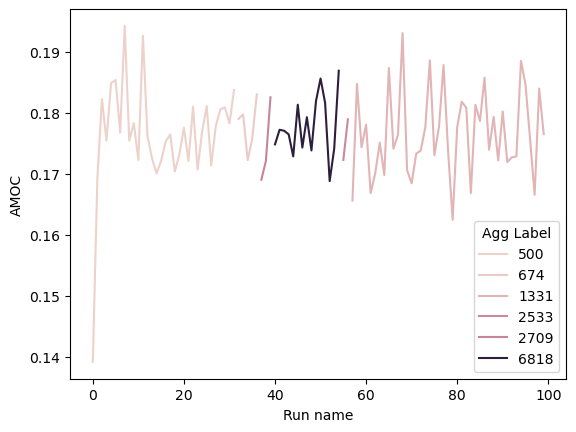

In [127]:
#make a lineage table to overlay on the normal lineplot
#filter to 1 trajectory
#save a df which has t: Run name, traj ID (one value in each df), Init label, Agg label
#plot this df
lineage=metadata_final.loc[metadata_final['Label']==500]
sns.lineplot(data=lineage,x='Run name',y='AMOC',hue='Agg Label')

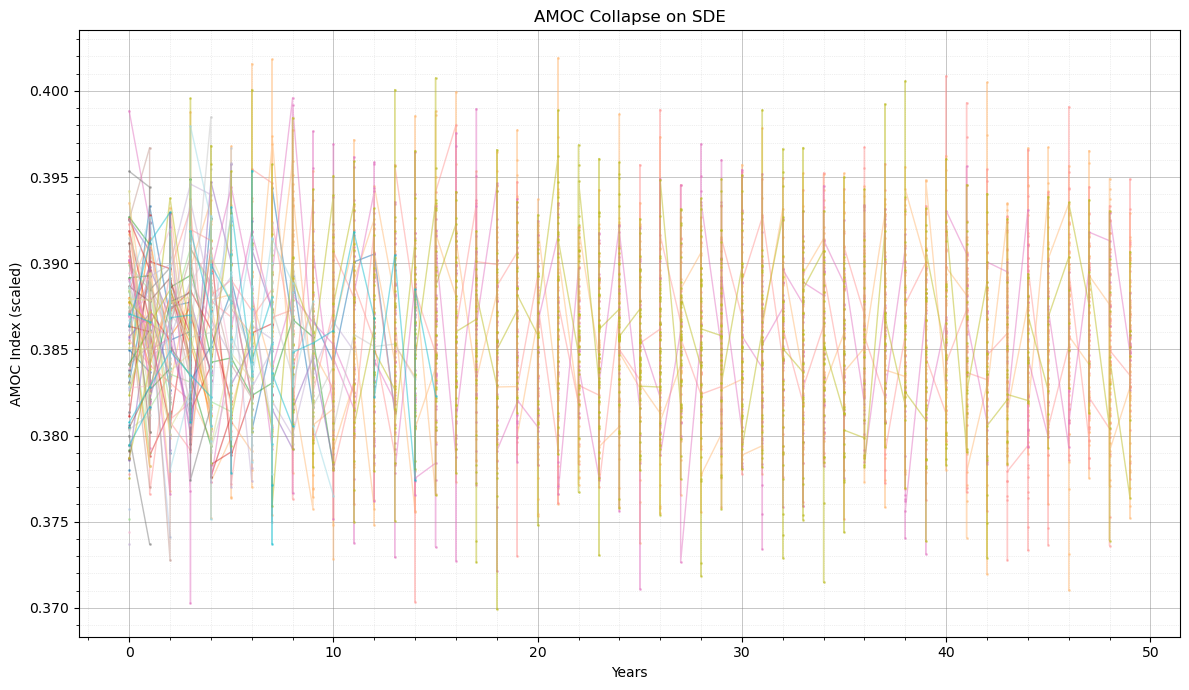

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

# Use a categorical colormap: one distinct color per original ancestor
ancestors = metadata_final["Agg Label"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(ancestors)))

for color, (ancestor, group) in zip(colors, metadata_final.groupby("Agg Label")):
    group = group.sort_values("Run name")

    ax.plot(
        group["Run name"],
        group["S"],
        color=color,

        linewidth=1,
        alpha=0.5,
        label=f"Ancestor {ancestor}",
        zorder=2,
        marker=".",
        markersize=2
    )

# Major and minor grid lines
ax.minorticks_on()
ax.grid(True, which="major", color="gray", linestyle="-", linewidth=0.7, alpha=0.45)
ax.grid(True, which="minor", color="gray", linestyle=":", linewidth=0.5, alpha=0.25)

ax.set_ylabel("AMOC Index (scaled)")
ax.set_xlabel("Years")
ax.set_title("AMOC Collapse on SDE")



fig.tight_layout()
plt.show()



In [140]:
#TO DO: Figure out the optimal k, run control run and get auto-correlation, finally run with RE alg
control_run = pd.read_csv('../data/control_run_SDE.csv')
amoc_list = np.array(control_run['AMOC'].tolist())
num_slices = 5
slice_length = len(amoc_list) // num_slices

#Split series into slices
slices = np.array_split(amoc_list, num_slices)

#Initialize array to store ACF for each slice
expectations = np.zeros((num_slices, slice_length))

for slice_num, s in enumerate(slices):
    s = np.array(s)
    mean_s = np.mean(s)
    var_s = np.var(s)

    #Compute autocovariance for each lag
    for lag in range(slice_length):
        #Take all overlapping pairs at this lag, s[:len(s)-lag] -> all except last values, (s[lag:]) -> all except first vals
        products = (s[:len(s)-lag] - mean_s) * (s[lag:] - mean_s)
        expectations[slice_num, lag] = np.mean(products) / var_s 

#Average ACF across slices
ACF = np.mean(expectations, axis=0)

Text(0, 0.5, 'Auto-correlation')

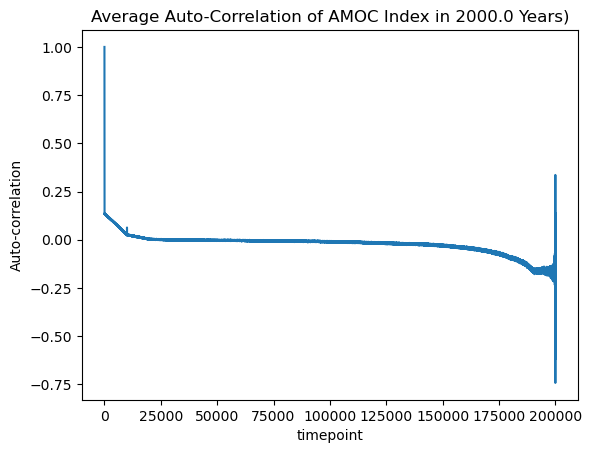

In [141]:
#plot autocorrelation function
title_var = slice_length/100
plt.figure()
plt.plot(ACF)
plt.title(f"Average Auto-Correlation of AMOC Index in {title_var} Years)")
plt.xlabel('timepoint')
plt.ylabel('Auto-correlation')
#plt.savefig('acfunc_salt.png')

In [ ]:
#integral auto-correlation time (system memory), tau
mults=[]
delta_t=0.01
for auto in range(len(ACF)):
    mults.append(ACF[auto]*delta_t)
tau = np.sum(mults)
print(tau)

In [ ]:
#compute k
#print(salt_variance)
#a = control_mean + 30*control_std_dev
a = mean_s - 30*np.sqrt(var_s)
#a = temp_mean - 30*temp_std
print(a)
#print(salt_std)
#print(a)
#k=a/(tau*control_variance)
k=a/(tau*var_s)
#k=a/(tau*salt_variance)
print(k)
#solve for a to find original anomaly
k=-500
a=k*(tau/var_s)
print(a)
anomaly = (a-mean_s)/np.sqrt(var_s)
print("anomalY:",anomaly)
#target value of a where trajectory drops to
k=(0.45)/tau/var_s
#target value of a where edge state
#k=(0.15)/tau/control_variance
#print(k)